In [5]:
import warnings
warnings.filterwarnings('ignore')
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Force Python to find your local 'src' directory
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_insurance_data

# Set styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# AlphaCare palette
PALETTE = {
    'primary': '#1d3557',     # Deep Blue
    'secondary': '#457b9d',   # Slate Blue
    'accent': '#e63946',      # Coral Red
    'background': '#f1faee'   # Light Off-White
}
sns.set_palette([PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']])

print("✅ AlphaCare EDA Environment Successfully Configured.")

✅ AlphaCare EDA Environment Successfully Configured.


In [2]:
# Load the dataset using your custom modular src module
df = load_insurance_data()

print("=== 📋 Dataset Structure ===")
print(df.info())

print("\n=== 🔍 Missing Value Scan ===")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values found!")

✅ Successfully loaded dataset from: ..\data\insurance_data.csv
=== 📋 Dataset Structure ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalCl

In [3]:
# Create the structural metrics columns
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# 1. Macro Portfolio Calculation
grand_premiums = df['TotalPremium'].sum()
grand_claims = df['TotalClaims'].sum()
portfolio_loss_ratio = grand_claims / grand_premiums
portfolio_margin = df['Margin'].sum()

print("=== 📊 Macro Portfolio Performance ===")
print(f"Total Premium Collected : R {grand_premiums:,.2f}")
print(f"Total Claims Settled     : R {grand_claims:,.2f}")
print(f"Overall Loss Ratio       : {portfolio_loss_ratio:.2%}")
print(f"Total Profit Margin      : R {portfolio_margin:,.2f}")

=== 📊 Macro Portfolio Performance ===
Total Premium Collected : R 24,881,279.00
Total Claims Settled     : R 13,141,885.00
Overall Loss Ratio       : 52.82%
Total Profit Margin      : R 11,739,394.00


C:\Users\hiwot\AppData\Local\Temp\ipykernel_16788\2930243754.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loss_Ratio', y=feature, data=grouped, ax=axes[idx], palette="Blues_r")
C:\Users\hiwot\AppData\Local\Temp\ipykernel_16788\2930243754.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loss_Ratio', y=feature, data=grouped, ax=axes[idx], palette="Blues_r")
C:\Users\hiwot\AppData\Local\Temp\ipykernel_16788\2930243754.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Loss_Ratio', y=feature, data=grouped, ax=axes[idx], pa

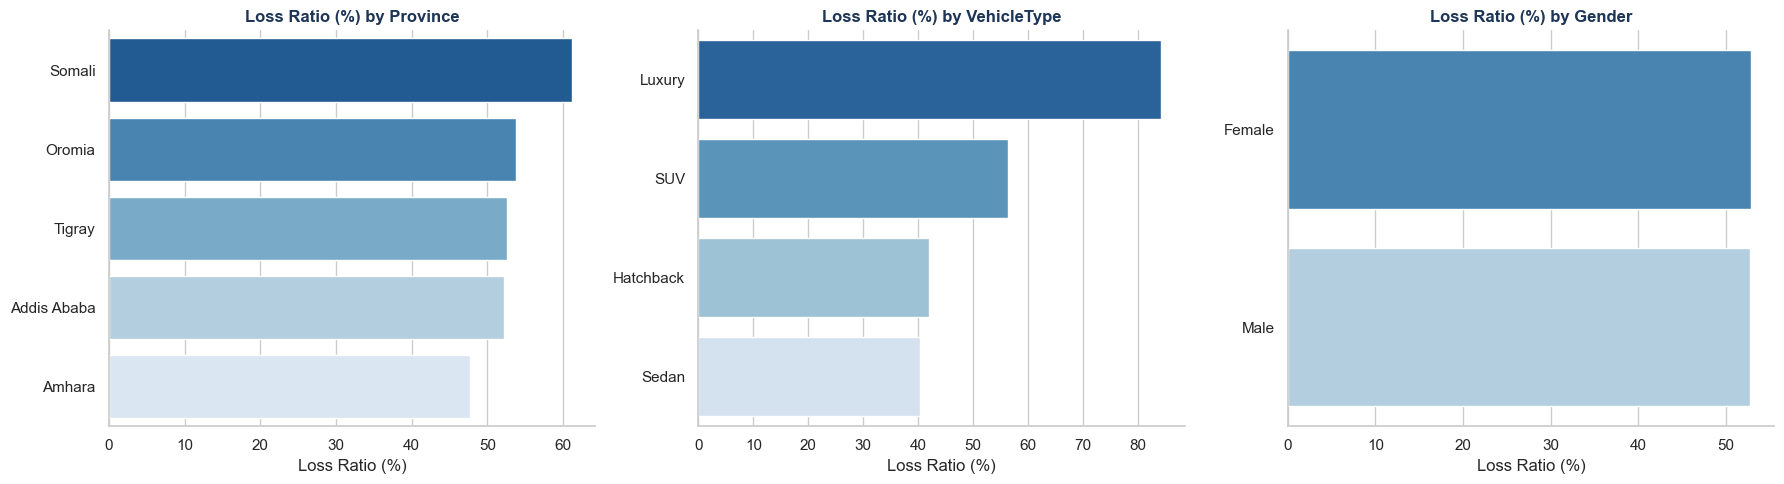

In [4]:
# Segment and calculate metrics across groups
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(['Province', 'VehicleType', 'Gender']):
    if feature in df.columns:
        grouped = df.groupby(feature).agg(
            Claims=('TotalClaims', 'sum'),
            Premiums=('TotalPremium', 'sum')
        )
        grouped['Loss_Ratio'] = (grouped['Claims'] / grouped['Premiums']) * 100
        grouped = grouped.sort_values(by='Loss_Ratio', ascending=False).reset_index()
        
        sns.barplot(x='Loss_Ratio', y=feature, data=grouped, ax=axes[idx], palette="Blues_r")
        axes[idx].set_title(f'Loss Ratio (%) by {feature}', fontsize=12, fontweight='bold', color=PALETTE['primary'])
        axes[idx].set_xlabel('Loss Ratio (%)')
        axes[idx].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

# Choose a segmentation column present in your data, e.g., 'CoverCategory' or 'Province'
hue_col = 'Province' if 'Province' in df.columns else None

sns.scatterplot(
    data=df, 
    x='TotalPremium', 
    y='TotalClaims', 
    hue=hue_col, 
    alpha=0.6, 
    palette='viridis' if hue_col else None
)

plt.title('Bivariate Analysis: Total Premium vs Total Claims', fontsize=14, fontweight='bold', color=PALETTE['primary'])
plt.xlabel('Total Premium (R)')
plt.ylabel('Total Claims (R)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

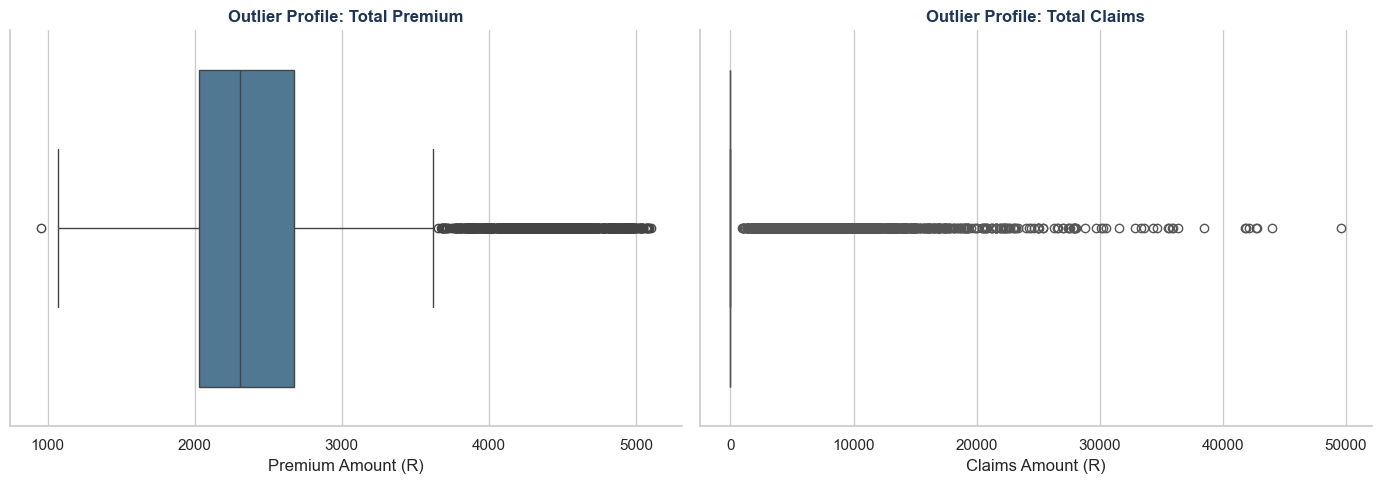

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Premium Distribution Boxplot
sns.boxplot(x=df['TotalPremium'], color=PALETTE['secondary'], ax=axes[0])
axes[0].set_title('Outlier Profile: Total Premium', fontsize=12, fontweight='bold', color=PALETTE['primary'])
axes[0].set_xlabel('Premium Amount (R)')

# Claims Settlement Boxplot
sns.boxplot(x=df['TotalClaims'], color=PALETTE['accent'], ax=axes[1])
axes[1].set_title('Outlier Profile: Total Claims', fontsize=12, fontweight='bold', color=PALETTE['primary'])
axes[1].set_xlabel('Claims Amount (R)')

plt.tight_layout()
plt.show()